In [1]:
import sys
import os
from pathlib import Path

# Project layout on AutoDL
project_root = "/root/projects"
solver_dir = os.path.join(project_root, "solver")
data_root = "/root/autodl-tmp/data"
output_root = "/root/autodl-tmp/outputs/test59"
checkpoint_root = "/root/autodl-tmp/checkpoints/test59"

for path in [project_root, solver_dir]:
    if path not in sys.path:
        sys.path.append(path)

os.makedirs(output_root, exist_ok=True)
os.makedirs(checkpoint_root, exist_ok=True)

print(f"project_root: {project_root}")
print(f"solver_dir: {solver_dir}")
print(f"data_root: {data_root}")
print(f"output_root: {output_root}")
print(f"checkpoint_root: {checkpoint_root}")


Specific directory added to sys.path: /mnt/d/Onedrive/ICPBR/Alberta/koopman_events/code/test/test40_new_EDMD_pipelines


In [2]:
import tensorflow as tf
import edmd_utils

# Use GPU on AutoDL
selected_device = 'gpu'

edmd_utils.set_device(selected_device)


2025-05-17 12:16:11.555799: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-17 12:16:11.628458: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-05-17 12:16:12.694893: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


edmd_utils module loaded
Using CPU


2025-05-17 12:16:14.227440: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] could not open file to read NUMA node: /sys/bus/pci/devices/0000:17:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-05-17 12:16:14.308513: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] could not open file to read NUMA node: /sys/bus/pci/devices/0000:17:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-05-17 12:16:14.308599: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] could not open file to read NUMA node: /sys/bus/pci/devices/0000:17:00.0/numa_node
Your kernel may have been built without NUMA support.


In [3]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from scipy.linalg import svd

In [4]:
# koopmanlib is already installed by pip in python directories
from koopmanlib.dictionary import PsiNN

solver_name = 'resdmd_batch'
KoopmanSolver = edmd_utils.import_solver(solver_name)

In [5]:
basis_function = PsiNN(layer_sizes=[100,100,100], n_psi_train=100)

In [ ]:
# Data configuration
# Only `obs` is used from the MAT file.
data_subdir = "f12m01"
data_filename = "f12m01_low50_high250_g2_abs_single.mat"

# Large MATLAB files are usually saved as v7.3 / HDF5 even if the suffix is .mat.
file_type = ".h5"
field_name = "obs"

data_input_path = os.path.join(data_root, data_subdir)
data_full_path = os.path.join(data_input_path, data_filename)

print(f"data_full_path: {data_full_path}")

In [ ]:
# Optional: inspect top-level keys once.
# For your current files, the main numeric array of interest is expected to be `obs`.
import h5py

with h5py.File(data_full_path, "r") as f:
    print(list(f.keys()))

In [6]:
# Load only the numeric observable matrix `obs`.
# The transpose keeps the downstream pipeline in the expected [time, features] layout.
DATA = edmd_utils.load_data(
    data_filename,
    data_input_path,
    file_type,
    field_name
).T.astype(np.float64)

print("Loaded DATA shape:", DATA.shape)

size of loaded data: (310, 5993061)


In [7]:
reduce_flag = False
if reduce_flag:
    n_modes = 10
    DATA_reduced = edmd_utils.dim_reduction(DATA, n_modes)

In [8]:
data_train, data_valid = edmd_utils.transfer_data_format(DATA, train_ratio=0.7)
print("Data shape: ", data_train[1].shape)

Data shape:  (4195142, 310)


In [9]:
solver = KoopmanSolver(dic=basis_function,
                         target_dim=np.shape(data_train)[-1],
                         reg=0.1)

In [10]:
N_round = 1
loss_all = []
val_loss_all = []

checkpoint_filepath = checkpoint_root
edmd_utils.remove_checkpoint(checkpoint_filepath)


Removed checkpoint directory: ./checkpoints_test/


In [11]:
KoopmanSolver = edmd_utils.import_solver(solver_name)

In [12]:
for n_round in range(N_round):
    print('Round number: ', n_round)
    
    # Remove checkpoint before starting new round

    
    temp_loss, temp_val_loss, stop_flag, lr_changes = solver.build(
        data_train=data_train,
        data_valid=data_valid,
        epochs=50,
        batch_size=100,
        lr=1e-4,
        log_interval=1,
        lr_decay_factor=.8,
        Nepoch=5,
        end_condition=1e-9)
        # checkpoint_dir='checkpoints'  # Ensure this matches the directory used in build()
    # )

    loss_all.extend(temp_loss)
    val_loss_all.extend(temp_val_loss)
    if stop_flag:
        break


Round number:  0
build: start
build: separate_data done, x_train shape=(4195142, 310), y_train shape=(4195142, 310)
build: zeros_data_y_train shape=(4195142, 411), zeros_data_y_valid shape=(1797918, 411)
build: compute_final_info start


compute_K batches: 100%|██████████| 4196/4196 [01:07<00:00, 61.74batch/s]


build: compute_final_info done, K shape=(411, 411)
build: build_model done


2025-05-17 12:25:26.007299: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x75008560 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
2025-05-17 12:25:26.007374: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): Host, Default Version
2025-05-17 12:25:26.022184: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:255] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-05-17 12:25:26.085039: I ./tensorflow/compiler/jit/device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


build: no checkpoint found, starting fresh
build: optimizer lr=0.0001
build: Outer Epoch 1/50
build: compute_K start


...

build: compute_K done
build: assigned K to Layer_K
build: train_psi start
Epoch 1/5
41952/41952 [==============================] - 517s 12ms/step - loss: 2.2884e-08 - val_loss: nan
Epoch 2/5
41952/41952 [==============================] - 503s 12ms/step - loss: 2.2876e-08 - val_loss: nan
Epoch 3/5
41952/41952 [==============================] - 496s 12ms/step - loss: 2.2869e-08 - val_loss: nan
Epoch 4/5
41952/41952 [==============================] - 496s 12ms/step - loss: 2.2861e-08 - val_loss: nan
Epoch 5/5
41952/41952 [==============================] - 500s 12ms/step - loss: 2.2857e-08 - val_loss: nan
build: train_psi done, history length=5
build: post-gc memory usage=101276.42578125 MiB
build: Outer Epoch 50/50
build: compute_K start


compute_K batches: 100%|██████████| 4196/4196 [01:08<00:00, 61.38batch/s]


build: compute_K done
build: assigned K to Layer_K
build: train_psi start
Epoch 1/5
41952/41952 [==============================] - 517s 12ms/step - loss: 2.2854e-08 - val_loss: nan
Epoch 2/5
41952/41952 [==============================] - 512s 12ms/step - loss: 2.2844e-08 - val_loss: nan
Epoch 3/5
41952/41952 [==============================] - 507s 12ms/step - loss: 2.2840e-08 - val_loss: nan
Epoch 4/5
41952/41952 [==============================] - 508s 12ms/step - loss: 2.2834e-08 - val_loss: nan
Epoch 5/5
41952/41952 [==============================] - 513s 12ms/step - loss: 2.2833e-08 - val_loss: nan
build: train_psi done, history length=5
build: post-gc memory usage=100903.375 MiB
build: final compute_final_info start


compute_K batches: 100%|██████████| 4196/4196 [01:15<00:00, 55.42batch/s]


build: final compute_final_info done
build: checkpoint saved


In [13]:
# for n_round in range(N_round):
#     print('Round number: ', n_round)
    
#     # Remove checkpoint before starting new round

    
#     temp_loss, temp_val_loss, stop_flag, lr_changes = solver.build(
#         data_train=data_train,
#         data_valid=data_valid,
#         epochs=2,
#         batch_size=200000,
#         lr=1e-4,
#         log_interval=1,
#         lr_decay_factor=.8,
#         Nepoch=10,
#         end_condition=1e-9)
#         # checkpoint_dir='checkpoints'  # Ensure this matches the directory used in build()
#     # )

#     loss_all.extend(temp_loss)
#     val_loss_all.extend(temp_val_loss)
#     if stop_flag:
#         break

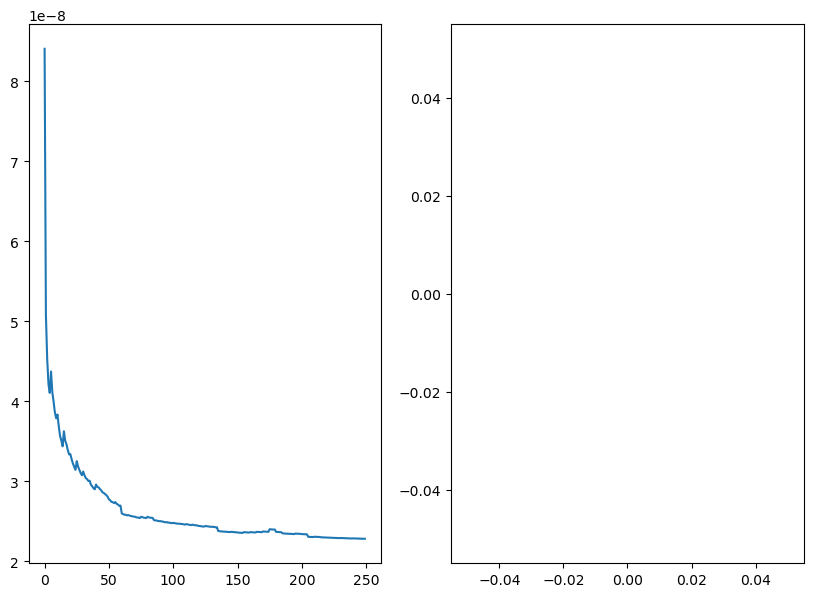

In [14]:
plt.figure(figsize=(10, 7))
plt.subplot(121)
plt.plot(loss_all[0:])

plt.subplot(122)
plt.plot(val_loss_all[0:])

In [ ]:
Psi = solver.dic.call(DATA).numpy().T
Psi_X = Psi[:, 0:-1]
Psi_Y = Psi[:, 1:]
print("PsiX shape: ", Psi_X.shape)

In [16]:
print(DATA.shape)

(5993061, 310)


In [17]:
chunk_size = 50000
import scipy.io
from pathlib import Path

num_chunks = int(np.ceil(DATA.shape[0] / float(chunk_size)))

evalues = solver.eigenvalues.T
kpm_modes = solver.compute_mode().T
N_dict = np.shape(evalues)[0]
out_base = Path(data_filename).stem

for i in range(num_chunks):
    start_idx = i * chunk_size
    end_idx = (i + 1) * chunk_size

    chunk_data = DATA[start_idx:end_idx, :]
    efuns = solver.eigenfunctions(chunk_data)
    EDMD_outputs = {
        'EDMD_outputs': {
            'efuns': efuns,
            'evalues': evalues,
            'kpm_modes': kpm_modes,
            'N_dict': N_dict,
            'loss': loss_all,
            'val_loss': val_loss_all
        }
    }

    out_file = os.path.join(
        output_root,
        f"{out_base}_Python_resdmd_Layer_100_Ndict_{N_dict}_outputs_{i+1}.mat"
    )
    scipy.io.savemat(out_file, EDMD_outputs)
    print(f"saved: {out_file}")


In [18]:
chunk_size = 50000
import scipy.io
from pathlib import Path

num_chunks = int(np.ceil(DATA.shape[0] / float(chunk_size)))

evalues = solver.eigenvalues.T
kpm_modes = solver.compute_mode().T
N_dict = np.shape(evalues)[0]
out_base = Path(data_filename).stem

for i in range(num_chunks):
    start_idx = i * chunk_size
    end_idx = (i + 1) * chunk_size

    chunk_data = DATA[start_idx:end_idx, :]
    Psi = solver.dic.call(chunk_data).numpy().T
    Psi_X = Psi[:, 0:-1]
    Psi_Y = Psi[:, 1:]
    EDMD_outputs = {
        'EDMD_outputs': {
            'Psi_X': Psi_X,
            'Psi_Y': Psi_Y
        }
    }

    out_file = os.path.join(
        output_root,
        f"{out_base}_Python_resdmd_Layer_100_Ndict_{N_dict}_outputs_Psi_{i+1}.mat"
    )
    scipy.io.savemat(out_file, EDMD_outputs)
    print(f"saved: {out_file}")
